In [ ]:
import os
import json
import joblib
import pandas as pd
import nltk
import numpy as np
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

In [ ]:
folder = "datasets"

# Selector global de predicción:    
# - "balanceado": mejor equilibrio general (accuracy/recall)
# - "alta_precision": reduce falsos positivos de la clase Falsa
MODO_PREDICCION = "alta_precision"


def normalizar_texto_basico(texto):
    """Elimina acentos para que el vectorizador y las stopwords coincidan."""
    texto = unicodedata.normalize("NFKD", texto)
    return "".join(caracter for caracter in texto if not unicodedata.combining(caracter)).lower()


# Cargamos stopwords en español; si no están disponibles, las descargamos una sola vez.
try:
    stop_words_es = [normalizar_texto_basico(palabra) for palabra in stopwords.words("spanish")]
except LookupError:
    nltk.download("stopwords", quiet=True)
    stop_words_es = [normalizar_texto_basico(palabra) for palabra in stopwords.words("spanish")]


def cargar_excel(parte_nombre):
    """Busca y carga el Excel que contiene la palabra clave indicada."""
    archivos = os.listdir(folder)
    coincidencias = [archivo for archivo in archivos if parte_nombre in archivo.lower() and archivo.lower().endswith(".xlsx")]
    if not coincidencias:
        print(f"No se encontró un archivo para '{parte_nombre}' en '{folder}'.")
        return None

    ruta = os.path.join(folder, coincidencias[0])
    df = pd.read_excel(ruta)
    df.columns = df.columns.str.strip().str.lower()
    return df


print("Cargando datasets...")
train_df = cargar_excel("train")
dev_df = cargar_excel("development")
test_df = cargar_excel("test")
print(f"Modo seleccionado: {MODO_PREDICCION}")

Cargando datasets...
Modo seleccionado: balanceado


In [38]:
# Normalizamos las etiquetas para que train, development y test usen el mismo mapeo.
mapeo_etiquetas = {"fake": 1, "false": 1, "true": 0}


def preparar_dataframe(df, nombre):
    """Limpia columnas clave y crea el texto combinado para el modelo."""
    if df is None:
        return None

    df = df.copy()
    df["label"] = df["category"].astype(str).str.strip().str.lower().map(mapeo_etiquetas)
    df["texto"] = df["headline"].fillna("").astype(str) + " " + df["text"].fillna("").astype(str)
    df = df.dropna(subset=["label", "texto"])
    df["label"] = df["label"].astype(int)

    print(f"{nombre}: {len(df)} filas listas para entrenar/evaluar")
    return df


train_df = preparar_dataframe(train_df, "train")
dev_df = preparar_dataframe(dev_df, "development")
test_df = preparar_dataframe(test_df, "test")

train: 676 filas listas para entrenar/evaluar
development: 295 filas listas para entrenar/evaluar
test: 572 filas listas para entrenar/evaluar


In [ ]:
from sklearn.metrics import balanced_accuracy_score, f1_score, brier_score_loss

# Modelo mejorado: mezcla de n-gramas de palabras y de caracteres para capturar contexto y variaciones del texto.
features = FeatureUnion([
    (
        "word_tfidf",
        TfidfVectorizer(
            stop_words=stop_words_es,
            ngram_range=(1, 2),
            max_features=60000,
            min_df=2,
            sublinear_tf=True,
            strip_accents="unicode",
        ),
    ),
    (
        "char_tfidf",
        TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            sublinear_tf=True,
            strip_accents="unicode",
        ),
    ),
])

modelo = Pipeline([
    ("features", features),
    ("clf", LogisticRegression(C=2.0, class_weight="balanced", max_iter=1000)),
])


EVALUACIÓN EN DEVELOPMENT
Accuracy (umbral 0.5): 0.7864
Balanced accuracy (umbral 0.5): 0.7865
Precision clase Falsa (umbral 0.5): 0.7724
Recall clase Falsa (umbral 0.5): 0.7887
F1 clase Falsa (umbral 0.5): 0.7805
Brier score clase Falsa: 0.1424
Umbral alta precision sugerido: 0.7503
Precision con umbral sugerido: 0.8776
Recall con umbral sugerido: 0.6056
              precision    recall  f1-score   support

   Verdadera     0.8000    0.7843    0.7921       153
       Falsa     0.7724    0.7887    0.7805       142

    accuracy                         0.7864       295
   macro avg     0.7862    0.7865    0.7863       295
weighted avg     0.7867    0.7864    0.7865       295



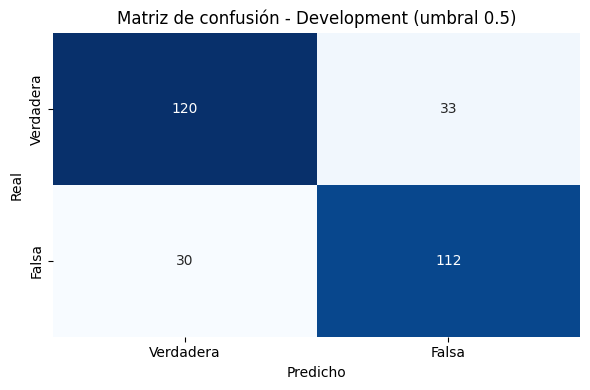

In [40]:
# Entrenamos con train y validamos con development para revisar el rendimiento antes del modelo final.
modelo.fit(train_df["texto"], train_df["label"])

proba_dev = modelo.predict_proba(dev_df["texto"])
indice_clase_falsa = list(modelo.classes_).index(1)
prob_falsa_dev = proba_dev[:, indice_clase_falsa]
dev_pred = (prob_falsa_dev >= 0.5).astype(int)
precision_fake_dev = precision_score(dev_df["label"], dev_pred, pos_label=1)
recall_fake_dev = recall_score(dev_df["label"], dev_pred, pos_label=1)

# Buscamos un umbral que priorice precision para la clase Falsa sin perder demasiado recall.
umbral_precision_alta = 0.5
mejor_precision = -1.0
mejor_recall = -1.0

for umbral in np.linspace(prob_falsa_dev.min(), prob_falsa_dev.max(), 200):
    pred_temp = (prob_falsa_dev >= umbral).astype(int)
    precision_temp = precision_score(dev_df["label"], pred_temp, pos_label=1, zero_division=0)
    recall_temp = recall_score(dev_df["label"], pred_temp, pos_label=1, zero_division=0)

    if recall_temp >= 0.58 and (precision_temp > mejor_precision or (precision_temp == mejor_precision and recall_temp > mejor_recall)):
        umbral_precision_alta = float(umbral)
        mejor_precision = float(precision_temp)
        mejor_recall = float(recall_temp)

# Si no se encuentra un umbral que cumpla la restricción de recall, usamos el modo balanceado.
if mejor_precision < 0:
    mejor_precision = float(precision_fake_dev)
    mejor_recall = float(recall_fake_dev)
    umbral_precision_alta = 0.5

print("\n" + "=" * 60)
print("EVALUACIÓN EN DEVELOPMENT")
print("=" * 60)
print(f"Accuracy (umbral 0.5): {accuracy_score(dev_df['label'], dev_pred):.4f}")
print(f"Balanced accuracy (umbral 0.5): {balanced_accuracy_score(dev_df['label'], dev_pred):.4f}")
print(f"Precision clase Falsa (umbral 0.5): {precision_fake_dev:.4f}")
print(f"Recall clase Falsa (umbral 0.5): {recall_fake_dev:.4f}")
print(f"F1 clase Falsa (umbral 0.5): {f1_score(dev_df['label'], dev_pred, pos_label=1):.4f}")
print(f"Brier score clase Falsa: {brier_score_loss(dev_df['label'], prob_falsa_dev):.4f}")
print(f"Umbral alta precision sugerido: {umbral_precision_alta:.4f}")
print(f"Precision con umbral sugerido: {mejor_precision:.4f}")
print(f"Recall con umbral sugerido: {mejor_recall:.4f}")
print(
    classification_report(
        dev_df["label"],
        dev_pred,
        target_names=["Verdadera", "Falsa"],
        digits=4,
    )
)

cm = confusion_matrix(dev_df["label"], dev_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Verdadera", "Falsa"],
    yticklabels=["Verdadera", "Falsa"],
)
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión - Development (umbral 0.5)")
plt.tight_layout()
plt.show()

In [ ]:
# Reentrenamos con train + development para guardar el modelo final con más datos.
train_total = pd.concat([train_df[["texto", "label"]], dev_df[["texto", "label"]]], ignore_index=True)

modelo.fit(train_total["texto"], train_total["label"])

# Guardamos modelo + configuración del umbral para reutilizar el modo elegido.
archivo_modelo = "clasificador_noticias_alta_precision.pkl"
artefacto = {
    "modelo": modelo,
    "umbral_precision_alta": umbral_precision_alta,
    "modo_default": MODO_PREDICCION,
}
joblib.dump(artefacto, archivo_modelo)
print(f"Modelo final guardado en {archivo_modelo}")
print(f"Umbral alta precision guardado: {umbral_precision_alta:.4f}")

Modelo final guardado en clasificador_noticias_balanceado.pkl
Umbral alta precision guardado: 0.7503


In [42]:
# Medimos el resultado final en test usando el modo configurado.
proba_test = modelo.predict_proba(test_df["texto"])
indice_clase_falsa = list(modelo.classes_).index(1)
prob_falsa_test = proba_test[:, indice_clase_falsa]
test_pred_balanceado = (prob_falsa_test >= 0.5).astype(int)
test_pred_alta_precision = (prob_falsa_test >= umbral_precision_alta).astype(int)

predicciones_por_modo = {
    "balanceado": test_pred_balanceado,
    "alta_precision": test_pred_alta_precision,
}

if MODO_PREDICCION not in predicciones_por_modo:
    raise ValueError("MODO_PREDICCION debe ser 'balanceado' o 'alta_precision'")

test_pred = predicciones_por_modo[MODO_PREDICCION]

print("\n" + "=" * 60)
print("EVALUACIÓN FINAL EN TEST")
print("=" * 60)
print(f"Modo activo: {MODO_PREDICCION}")
print(f"Umbral aplicado: {0.5 if MODO_PREDICCION == 'balanceado' else umbral_precision_alta:.4f}")
print(f"Accuracy: {accuracy_score(test_df['label'], test_pred):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(test_df['label'], test_pred):.4f}")
print(f"Precision clase Falsa (1): {precision_score(test_df['label'], test_pred, pos_label=1):.4f}")
print(f"Recall clase Falsa (1): {recall_score(test_df['label'], test_pred, pos_label=1):.4f}")
print(f"F1 clase Falsa (1): {f1_score(test_df['label'], test_pred, pos_label=1):.4f}")
print(f"Brier score clase Falsa: {brier_score_loss(test_df['label'], prob_falsa_test):.4f}")
print(
    classification_report(
        test_df["label"],
        test_pred,
        target_names=["Verdadera", "Falsa"],
        digits=4,
    )
)

# Comparativa rápida para ver el costo/beneficio del otro modo.
print("\nResumen rápido de ambos modos:")
print(
    f"- balanceado -> acc={accuracy_score(test_df['label'], test_pred_balanceado):.4f}, "
    f"precision_falsa={precision_score(test_df['label'], test_pred_balanceado, pos_label=1):.4f}, "
    f"recall_falsa={recall_score(test_df['label'], test_pred_balanceado, pos_label=1):.4f}, "
    f"brier={brier_score_loss(test_df['label'], prob_falsa_test):.4f}"
)
print(
    f"- alta_precision -> acc={accuracy_score(test_df['label'], test_pred_alta_precision):.4f}, "
    f"precision_falsa={precision_score(test_df['label'], test_pred_alta_precision, pos_label=1):.4f}, "
    f"recall_falsa={recall_score(test_df['label'], test_pred_alta_precision, pos_label=1):.4f}, "
    f"brier={brier_score_loss(test_df['label'], prob_falsa_test):.4f}"
)


EVALUACIÓN FINAL EN TEST
Modo activo: balanceado
Umbral aplicado: 0.5000
Accuracy: 0.7343
Balanced accuracy: 0.7343
Precision clase Falsa (1): 0.7839
Recall clase Falsa (1): 0.6469
F1 clase Falsa (1): 0.7088
Brier score clase Falsa: 0.1820
              precision    recall  f1-score   support

   Verdadera     0.6994    0.8217    0.7556       286
       Falsa     0.7839    0.6469    0.7088       286

    accuracy                         0.7343       572
   macro avg     0.7417    0.7343    0.7322       572
weighted avg     0.7417    0.7343    0.7322       572


Resumen rápido de ambos modos:
- balanceado -> acc=0.7343, precision_falsa=0.7839, recall_falsa=0.6469, brier=0.1820
- alta_precision -> acc=0.6608, precision_falsa=0.8898, recall_falsa=0.3671, brier=0.1820


In [43]:
# Evaluamos noticias nuevas desde un JSON usando el modelo ya entrenado.
ruta_json = "noticias.json"

if not os.path.exists(ruta_json):
    raise FileNotFoundError(f"No se encontró {ruta_json}")

with open(ruta_json, "r", encoding="utf-8") as f:
    noticias = json.load(f)

# Si no existe el modelo en memoria, lo cargamos desde el artefacto guardado.
if "modelo" not in globals() or modelo is None:
    artefacto_cargado = joblib.load(archivo_modelo)
    if isinstance(artefacto_cargado, dict) and "modelo" in artefacto_cargado:
        modelo = artefacto_cargado["modelo"]
        umbral_precision_alta = artefacto_cargado.get("umbral_precision_alta", 0.5)
        MODO_PREDICCION = artefacto_cargado.get("modo_default", "balanceado")
    else:
        modelo = artefacto_cargado
        umbral_precision_alta = 0.5

# Preparamos texto de entrada con title + text.
registros = []
for noticia in noticias:
    titulo = str(noticia.get("title", "")).strip()
    texto = str(noticia.get("text", "")).strip()
    if not (titulo or texto):
        continue
    texto_modelo = f"{titulo} {texto}".strip()
    registros.append(
        {
            "id": noticia.get("id"),
            "titulo": titulo,
            "texto_modelo": texto_modelo,
            "url": noticia.get("url", ""),
        }
    )

if not registros:
    raise ValueError("No hay noticias con contenido válido en el JSON.")

df_noticias = pd.DataFrame(registros)

# Predicción por umbral según el modo activo.
proba_json = modelo.predict_proba(df_noticias["texto_modelo"])
indice_clase_falsa = list(modelo.classes_).index(1)
indice_clase_verdadera = list(modelo.classes_).index(0)
prob_falsa_json = proba_json[:, indice_clase_falsa]
prob_verdadera_json = proba_json[:, indice_clase_verdadera]
pred_json_balanceado = (prob_falsa_json >= 0.5).astype(int)
pred_json_alta_precision = (prob_falsa_json >= umbral_precision_alta).astype(int)

predicciones_json = {
    "balanceado": pred_json_balanceado,
    "alta_precision": pred_json_alta_precision,
}

if MODO_PREDICCION not in predicciones_json:
    MODO_PREDICCION = "balanceado"

pred_json = predicciones_json[MODO_PREDICCION]

# Convertimos salida numérica a etiqueta legible.
etiquetas = {0: "VERDADERA", 1: "FALSA"}
df_noticias["prediccion"] = [etiquetas[int(p)] for p in pred_json]
df_noticias["probabilidad_falsa"] = prob_falsa_json
df_noticias["probabilidad_verdadera"] = prob_verdadera_json
df_noticias["credibilidad_noticia"] = df_noticias["probabilidad_verdadera"]
df_noticias["credibilidad_noticia_pct"] = (df_noticias["credibilidad_noticia"] * 100).round(2)
df_noticias["score_modelo"] = df_noticias["credibilidad_noticia"]
df_noticias["confianza_absoluta"] = df_noticias["credibilidad_noticia"]

print("\n" + "=" * 70)
print("EVALUACIÓN DE NOTICIAS DEL JSON")
print("=" * 70)
print(f"Modo activo: {MODO_PREDICCION}")
print(f"Total noticias evaluadas: {len(df_noticias)}")
print("Resumen de predicciones:")
print(df_noticias["prediccion"].value_counts())

print("\nTop 10 noticias con mayor credibilidad:")
print(
    df_noticias[["id", "titulo", "prediccion", "credibilidad_noticia_pct"]]
    .sort_values("credibilidad_noticia_pct", ascending=False)
    .to_string(index=False)
)

print("\nNota: el porcentaje representa credibilidad general estimada de la noticia (0 a 100), no una verdad absoluta.")

# Si quieres explorar todas, deja esta variable en memoria.
resultado_noticias = df_noticias


EVALUACIÓN DE NOTICIAS DEL JSON
Modo activo: balanceado
Total noticias evaluadas: 26
Resumen de predicciones:
prediccion
FALSA        13
VERDADERA    13
Name: count, dtype: int64

Top 10 noticias con mayor credibilidad:
       id                                                                                   titulo prediccion  credibilidad_noticia_pct
405472342                                        Analizan pobreza en municipios mineros del estado  VERDADERA                     97.59
405513414                                Muere 'El Mencho' camino a CDMX tras operativo en Jalisco  VERDADERA                     97.39
405452588                                         Abaten a Nemesio Oseguera Cervantes, “El Mencho”  VERDADERA                     96.97
405460064                                                  Será el martes elección en el Campestre  VERDADERA                     96.32
405452586                        San Mateo Atenco inaugura rehabilitación de avenida Benito Juárez 